<a href="https://colab.research.google.com/github/tommeco/cybersecurity-daily/blob/main/stenografiaday4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from PIL import Image
import numpy as np
import os


try:
  from PIL import image
  print("Pillow già installato")
except ImportError:
  os.system("pip install Pillow --quiet")
  from PIL import Image
  print("Pillow installato")

print("Librerie pronte!")

Immagine creata: immagine_originale.png(200 x 200 pixel)


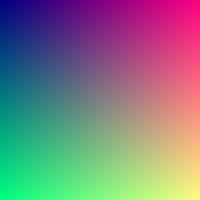

In [ ]:
def crea_immagine_test(nome_file="immagine_originale.png",
                       larghezza=200, altezza=200):
  img= Image.new("RGB", (larghezza, altezza))
  pixels = img.load()

  for i in range(larghezza):
    for j in range(altezza):
      r = int((i / larghezza)*255)
      g = int((j / altezza)* 255)
      b = 128
      pixels[i,j] = (r,g,b)


  img.save(nome_file)
  print(f"Immagine creata: {nome_file}({larghezza} x {altezza} pixel)")
  return img


img_originale = crea_immagine_test()
img_originale



In [ ]:
def testo_in_bit(testo):
  FINE = "11111111111111110"

  bit = ""
  for carattere in testo:
    bit += format(ord(carattere), '08b')

  return bit + FINE

def bit_in_testo(bit):
  FINE = "11111111111111110"
  testo = ""

  for i in range(0, len(bit)- 16, 8):
    byte = bit[i:i+8]

    if bit[i:i+16] == FINE:
      break
    testo += chr(int(byte, 2))

  return testo

  messaggio = "Ciao!"
  bit = testo_in_bit(messaggio)
  print(f"Testo originale: {messaggio}")
  print(f"In bit    : {bit[:40]}...")
  print(f"lunghezza bit    : {len(bit)}")
  print(f"Riconvertito    : {bit_in_testo(bit)}")


Messaggio nascosto con successo!
  Testo     : 'Questo messaggio e' nascosto nell'immagine!'
  Bit usati : 361
  Pixel usati: 361 / 40000 totali
  Output    : immagine_steganografata.png


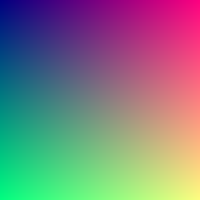

In [ ]:
def nascondi_messaggio(img_path, messaggio, output_path="immagine_steganografata.png"):

    img = Image.open(img_path).convert("RGB")
    pixels = list(img.getdata())

    bit_messaggio = testo_in_bit(messaggio)
    n_bit = len(bit_messaggio)

    # verifica che l'immagine sia abbastanza grande
    if n_bit > len(pixels):
        raise ValueError(
            f"Messaggio troppo lungo! "
            f"Serve almeno {n_bit} pixel, "
            f"l'immagine ne ha {len(pixels)}."
        )

    nuovi_pixels = []
    bit_index = 0

    for pixel in pixels:
        r, g, b = pixel

        if bit_index < n_bit:
            # modifica l'LSB del canale rosso
            # AND con 11111110 azzera l'ultimo bit
            # OR con il bit del messaggio lo imposta
            r = (r & 0b11111110) | int(bit_messaggio[bit_index])
            bit_index += 1

        nuovi_pixels.append((r, g, b))

    # ricostruisce l'immagine con i pixel modificati
    img_output = Image.new("RGB", img.size)
    img_output.putdata(nuovi_pixels)
    img_output.save(output_path)

    print(f"Messaggio nascosto con successo!")
    print(f"  Testo     : '{messaggio}'")
    print(f"  Bit usati : {n_bit}")
    print(f"  Pixel usati: {n_bit} / {len(pixels)} totali")
    print(f"  Output    : {output_path}")

    return img_output


# ── Test ──────────────────────────────────────────────
messaggio_segreto = "Questo messaggio e' nascosto nell'immagine!"
img_steganografata = nascondi_messaggio(
    "immagine_originale.png",
    messaggio_segreto
)
img_steganografata

In [15]:
def estrai_messaggio(img_path):
  img = Image.open(img_path).convert("RGB")
  pixels = list(img.getdata())

  bit_estratti = ""

  for pixel in pixels:
    r, g, b = pixel
    bit_estratti += str(r & 1)

  messaggio = bit_in_testo(bit_estratti)
  return messaggio


print("ENCODE:")
nascondi_messaggio("immagine_originale.png",
                   "Messaggio segreto: LSB funziona!",
                   "test_steg.png")

print("\nDECODE:")
messaggio_estrattoi = estrai_messaggio("test_steg.png")
print(f"Messaggio estratto: '{messaggio_estrattoi}")

ENCODE:
Messaggio nascosto con successo!
  Testo     : 'Messaggio segreto: LSB funziona!'
  Bit usati : 273
  Pixel usati: 273 / 40000 totali
  Output    : test_steg.png

DECODE:
Messaggio estratto: 'Messaggio segreto: LSB funziona!ÿÿRZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-ZKIi-¥´¶ÒZKIi-¥´¶ÒZKIi-

In [27]:
def confronta_immagini(img1_path, img2_path):
  img1 = np.array(Image.open(img1_path).convert("RGB"))
  img2 = np.array(Image.open(img2_path).convert("RGB"))

  differenza = np.abs(img1.astype(int)- img2.astype(int))
  pixel_modificati = np.any(differenza > 0, axis=2).sum()
  totale_pixel= img1.shape[0] * img1.shape[1]
  diff_max = differenza.max()
  diff_media = differenza.mean()

  print("=" * 55)
  print("  CONFRONTO IMMAGINI")
  print("=" * 55)
  print(f"  Pixel totali     : {totale_pixel}")
  print(f"  Pixel modificati  : {pixel_modificati}")
  print(f"  Percentuale       : {pixel_modificati/totale_pixel*100:.2f}%")
  print(f"  Differenza max    : {diff_max} (su 255)")
  print(f"  Differenza media  : {diff_media:.6f}")
  print(f"\n  Visivamente identiche? {'SI' if diff_max <= 1 else 'NO'}")
  print("=" * 55)


confronta_immagini("immagine_originale.png", "test_steg.png")

  CONFRONTO IMMAGINI
  Pixel totali     : 40000
  Pixel modificati  : 126
  Percentuale       : 0.32%
  Differenza max    : 1 (su 255)
  Differenza media  : 0.001050

  Visivamente identiche? SI


In [31]:
def crea_sfida():
  nascondi_messaggio(
      "immagine_originale.png",
      "Hai trovato il messaggio segreto! Sei un vero hacker etico."
      "sfida_finale.png"

  )
  print("immagine sfida creata: sfida_finale.png")
  print("Riesci a estrarre il messaggio nascosto?\n")

  crea_sfida()
